# ENG2440 Assignment 1 — Pneumonia Classification Challenge

**Author:** Brandon Jason  
**Dataset:** RSNA 2018 Pneumonia Detection Challenge

Binary target: `y = 1` if any annotation row for a `patientId` has `Target = 1`, else `y = 0`.  
Splitting unit: **`nih_patient_id`** (from the RSNA→NIH mapping) — not `patientId`, which is a per-exam identifier.

---
*This scaffold contains only the config + verification cells provided in the assignment (Steps 4–5)*

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
BASE = "/Users/adebayo/Desktop/ENG2440_Assignment1:"
os.environ["DATA_ROOT"]    = f"{BASE}/data/images"
os.environ["LABEL_FILE"]   = f"{BASE}/assignment1_labels.csv"
os.environ["MAPPING_FILE"] = f"{BASE}/rsna_to_nih_mapping.csv"
print("Local paths set")

Local paths set


## Configuration

Only `DATA_ROOT` should change between machines. On the HPC (interactive srun/salloc session), set it with an environment variable so no code edits are needed:
```bash
export DATA_ROOT=/scratch/your_user/rsna/images
```

In [3]:
import pandas as pd
import os
from pathlib import Path

# Only DATA_ROOT changes between local machine and HPC.
# This notebook lives in ENG2440_Assignment1_Supporting_Files/, so local defaults point one level up.
DATA_ROOT    = Path(os.environ.get("DATA_ROOT", "../data/images"))
LABEL_FILE   = Path(os.environ.get("LABEL_FILE", "../assignment1_labels.csv"))
MAPPING_FILE = Path(os.environ.get("MAPPING_FILE", "../rsna_to_nih_mapping.csv"))

print("DATA_ROOT   :", DATA_ROOT.resolve())
print("LABEL_FILE  :", LABEL_FILE.resolve())
print("MAPPING_FILE:", MAPPING_FILE.resolve())

DATA_ROOT   : /Users/adebayo/Desktop/ENG2440_Assignment1:/data/images
LABEL_FILE  : /Users/adebayo/Desktop/ENG2440_Assignment1:/assignment1_labels.csv
MAPPING_FILE: /Users/adebayo/Desktop/ENG2440_Assignment1:/rsna_to_nih_mapping.csv


## Verify the download (assignment Step 5)

In [4]:
dicom_files = list(DATA_ROOT.rglob("*.dcm"))
print("DICOM files found:", len(dicom_files))
print("Label file found:", LABEL_FILE.exists())
print("Mapping file found:", MAPPING_FILE.exists())

assert len(dicom_files) > 0, "No DICOM files were found."
assert LABEL_FILE.exists(), "The label file was not found."
assert MAPPING_FILE.exists(), "The mapping file was not found."
print("\nAll checks passed — dataset is ready.")

DICOM files found: 25684
Label file found: True
Mapping file found: True

All checks passed — dataset is ready.


---
# Task A — Define the task and inspect the data



"First of all there would be an input, a frontal Chest X-ray supplied as a DICOM Image"

"The expected output is a binary label , 'positive'='lung opacity consistent with possible Pneumonia' and  'Negative' = 'No such opacity'"

'The clinical Question is : Does this Chest Xray contian a lung opacity that a radiologist would classify as possibly having pneumonia?"

25684
11171
Target
0    20025
1     5659
Name: count, dtype: int64
Indexed files: 25684
Image sizes (rows x cols):
1024 x 1024    25684
Name: count, dtype: int64 

Photometric interpretation:
photometric
MONOCHROME2    25684
Name: count, dtype: int64 

View position:
view
PA    13979
AP    11705
Name: count, dtype: int64


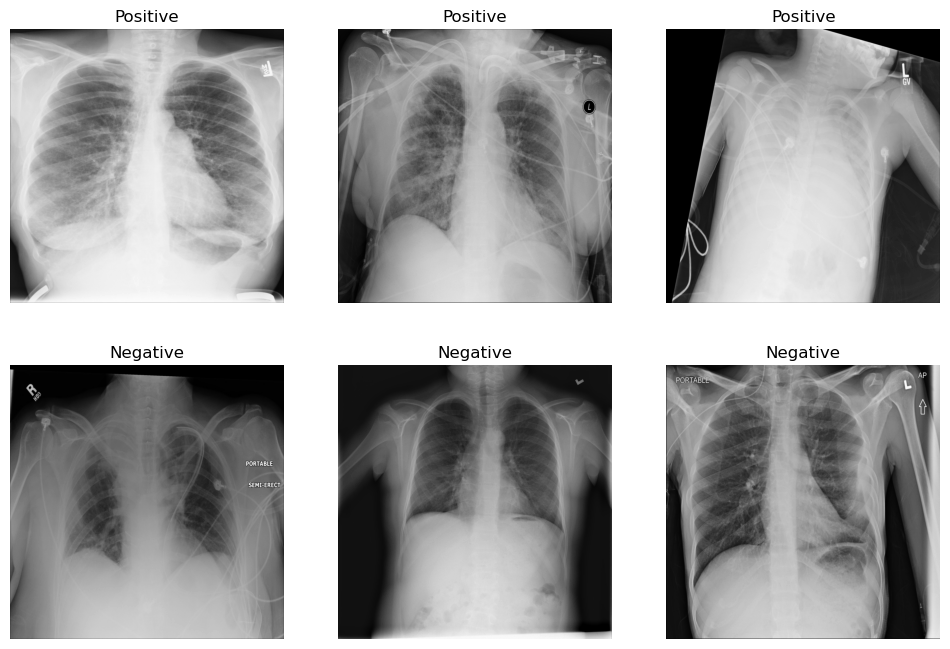

In [5]:
LABELS = pd.read_csv(LABEL_FILE)
MAPPINGS = pd.read_csv(MAPPING_FILE)
import pydicom
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from pathlib import Path

collapsed=LABELS.groupby('patientId')["Target"].max().reset_index()

merged=pd.merge(collapsed,MAPPINGS,on='patientId',how='left',validate='one_to_one')
assert merged.shape[0] == 25684
assert merged['nih_patient_id'].isna().sum() == 0

print(merged["patientId"].nunique())
print(merged["nih_patient_id"].nunique())
print(merged["Target"].value_counts())
merged["Target"].value_counts(normalize=True)



path_index = {p.stem: p for p in DATA_ROOT.rglob("*.dcm")}
assert len(path_index) == 25684
print("Indexed files:", len(path_index))

pos_ids = merged.loc[merged["Target"] == 1, "patientId"].tolist()
neg_ids = merged.loc[merged["Target"] == 0, "patientId"].tolist()
chosen  = pos_ids[:3] + neg_ids[:3]



fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, pid in zip(axes.ravel(), chosen):
    arr   = pydicom.dcmread(path_index[pid]).pixel_array
    label = merged.loc[merged["patientId"] == pid, "Target"].iloc[0]

    ax.imshow(arr, cmap="gray")
    ax.set_title("Positive" if label == 1 else "Negative")
    ax.axis("off")

records = []
for pid, path in path_index.items():
    ds = pydicom.dcmread(path, stop_before_pixels=True)  
    records.append({
        "patientId":   pid,
        "rows":        ds.get("Rows"),
        "cols":        ds.get("Columns"),
        "photometric": ds.get("PhotometricInterpretation", "UNKNOWN"),
        "view":        ds.get("ViewPosition", "UNKNOWN"),
    })

meta = pd.DataFrame(records)

print("Image sizes (rows x cols):")
print((meta["rows"].astype(str) + " x " + meta["cols"].astype(str)).value_counts(), "\n")

print("Photometric interpretation:")
print(meta["photometric"].value_counts(), "\n")

print("View position:")
print(meta["view"].value_counts())


---
# Task B — Create leakage-safe splits

Split train/validation/test by **`nih_patient_id`** (patient-level), so no patient appears in more than one split. Assertions below prove the three patient sets are disjoint.

In [8]:
import sklearn
from sklearn.model_selection import GroupShuffleSplit
SEED = 42
gss_test=GroupShuffleSplit(n_splits=1,test_size=0.15,random_state=SEED)
temp_idx,test_idx=next((gss_test.split(merged,None,merged["nih_patient_id"])))

temp_df=merged.iloc[temp_idx]
test_df=merged.iloc[test_idx]
print("temp:", temp_df.shape[0], "exams")
print("test:", test_df.shape[0], "exams")


gss_val=GroupShuffleSplit(n_splits=1,test_size=15/85,random_state=SEED)
train_idx,val_idx=next((gss_val.split(temp_df,None,temp_df["nih_patient_id"])))

val_df=temp_df.iloc[val_idx]
train_df=temp_df.iloc[train_idx]

print("train:", train_df.shape[0], "exams")
print("val:", val_df.shape[0], "exams")


train_patients=set(train_df["nih_patient_id"])
val_patients=set(val_df["nih_patient_id"])
test_patients=set(test_df["nih_patient_id"])

assert len(train_patients.intersection(val_patients)) == 0
assert len(train_patients.intersection(test_patients)) == 0
assert len(val_patients.intersection(test_patients)) == 0

print("Train, val, and test patient sets are disjoint")

splits = {"train": train_df, "val": val_df, "test": test_df}
for name, df in splits.items():
    size     = df.shape[0]
    pos_prop = df["Target"].mean()
    print(f"{name:5s}  size: {size:6d}  positive proportion: {pos_prop:.3f}")







temp: 21833 exams
test: 3851 exams
train: 17947 exams
val: 3886 exams
Train, val, and test patient sets are disjoint
train  size:  17947  positive proportion: 0.217
val    size:   3886  positive proportion: 0.218
test   size:   3851  positive proportion: 0.239


### B5 — A leakage route that patient-level grouping does not prevent

Grouping by `nih_patient_id` stops the **same patient** appearing in more than one
split, but in a multi-site dataset it does **not** prevent **site/scanner leakage**.
Different sites use different scanners, exposure settings and burned-in markers
(e.g. "PORTABLE", side/orientation labels), which form an *acquisition fingerprint*.
If disease prevalence differs by site, the model can learn "this scanner signature →
positive" instead of reading the lungs. Because every split still contains all sites,
this shortcut survives into the test set and inflates the reported performance.

**How to test for it:** hold out an entire site from training and evaluate on that
unseen site (leave site out). If performance drops sharply on the held-out site
compared with same-site evaluation, the model is relying on site specific signal
rather than pathology. This requires a site/scanner label; if none is provided, a
proxy such as the DICOM manufacturer field or clustering images by acquisition
artefacts could stand in.



---
# Task C — Preprocess and augment

**C1:** DICOM → model-ready tensor. Pixels are min-max scaled to **[0, 1]** (per image, independent of bit depth), then resized to **224×224** with antialiasing and given a channel dimension → tensor of shape `(1, 224, 224)`.

In [9]:

import numpy as np
import torch
import torchvision.transforms.functional as TF

def load_and_scale(pid):
    arr = pydicom.dcmread(path_index[pid]).pixel_array   
    arr = arr.astype("float32")                          
    arr = (arr - arr.min()) / (arr.max() - arr.min())    
    return arr
def preprocess(pid):
    arr=load_and_scale(pid)
    t=torch.from_numpy(arr).unsqueeze(0)
    t=TF.resize(t, (224, 224),antialias=True)
    return t
from torchvision import transforms 
import matplotlib.pyplot as plt
train_tf = transforms.RandomAffine(degrees=10, translate=(0.05, 0.05),fill=0)

img=preprocess(pos_ids[0])
aug=train_tf(img)

fig, (a,b) =plt.subplots(1,2,figsize=(8,4))
a.imshow(img.squeeze(),cmap="gray"); a.set_title("Original")
a.axis("off")
b.imshow(aug.squeeze(),cmap="gray"); b.set_title("Augmented (rotate ±10°, shift ±5%)"); b.axis("off")
plt.tight_layout();plt.show()



pos_weight = (train_df["Target"] == 0).sum() / (train_df["Target"] == 1).sum()
print(pos_weight)   


: 

The augmentations I applied are a small rotation (±10°) and a small translation (±5%). These mimic realistic acquisition variation: a patient may not lie perfectly still during the scan and, in the worst case, may be tilted or slightly off-centre against the detector. Neither transform alters the underlying anatomy.
I deliberately avoided vertical flips, horizontal flips, and heavy rotation, because they produce anatomically implausible images  positions a real patient could not be scanned in. In particular, a horizontal flip mirrors left and right, which would move the heart to the right side , changing the clinical meaning of the image. A vertical flip would present an upside-down chest, which is impossible. Augmentations must expand realistic variation without inventing anatomy that does not occur, so these were excluded.

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score,recall_score,confusion_matrix
y_true=test_df["Target"].values
marjority_class=train_df["Target"].mode()[0]
y_pred = np.full(len(y_true),marjority_class)

accuracy=accuracy_score(y_true,y_pred)
recall=recall_score(y_true,y_pred)
tn, fp, fn, tp = confusion_matrix(y_true,y_pred).ravel()
specificity=tn/(tn+fp)
print(f"Accuracy: {accuracy:.3f}")
print(f"Recall: {recall:.3f}")
print(f"Specificity: {specificity:.3f}")
def extract_features(pid):
     arr=load_and_scale(pid)
     return np.array([arr.mean(),arr.std(),np.percentile(arr,10),np.percentile(arr,50),np.percentile(arr,90),])
     


X_train = np.array([extract_features(pid) for pid in train_df["patientId"]])
y_train = train_df["Target"].values

X_val = np.array([extract_features(pid) for pid in val_df["patientId"]])
y_val = val_df["Target"].values

X_test = np.array([extract_features(pid) for pid in test_df["patientId"]])
y_test = test_df["Target"].values

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape,   "y_val:  ", y_val.shape)
print("X_test: ", X_test.shape,  "y_test: ", y_test.shape)

np.savez("baseline_features.npz", X_train=X_train, y_train=y_train,
         X_val=X_val, y_val=y_val, X_test=X_test, y_test=y_test)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   
X_val_s   = scaler.transform(X_val)         
X_test_s  = scaler.transform(X_test) 


import torch, torch.nn as nn
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix

# --- features/labels to tensors ---
Xtr = torch.tensor(X_train_s, dtype=torch.float32)
ytr = torch.tensor(y_train,   dtype=torch.float32).unsqueeze(1)
Xva = torch.tensor(X_val_s,   dtype=torch.float32)
Xte = torch.tensor(X_test_s,  dtype=torch.float32)


def train_logistic(pos_weight=None, epochs=300, lr=0.01):
    torch.manual_seed(42)                     
    model = nn.Linear(5, 1)
    pw = torch.tensor([pos_weight], dtype=torch.float32) if pos_weight else None
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pw)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for _ in range(epochs):
        model.train()
        opt.zero_grad()
        loss = loss_fn(model(Xtr), ytr)
        loss.backward()
        opt.step()
    return model


def evaluate(model, X, y_true):
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(X)).squeeze().numpy()
    y_pred = (probs >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {"accuracy":    round(accuracy_score(y_true, y_pred), 3),
            "sensitivity": round(recall_score(y_true, y_pred, zero_division=0), 3),
            "specificity": round(tn / (tn + fp), 3)}


model_plain    = train_logistic(pos_weight=None)
model_weighted = train_logistic(pos_weight=3.615)

print("C4 comparison (validation):")
print("  WITHOUT pos_weight:", evaluate(model_plain,    Xva, y_val))
print("  WITH    pos_weight:", evaluate(model_weighted, Xva, y_val))


final_model = model_weighted
print("\nFinal logistic baseline (TEST, evaluated once):")
print(" ", evaluate(final_model, Xte, y_test))






In [1]:
import torch
print("CUDA:", torch.cuda.is_available(), "|", torch.cuda.get_device_name(0))

CUDA: True | NVIDIA RTX 5000 Ada Generation


In [ ]:
import torch.nn as nn
from torchvision import models

device = torch.device("cuda")

def build_model():
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    old_w = m.conv1.weight.data
    m.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    m.conv1.weight.data = old_w.mean(dim=1, keepdim=True)
    m.fc = nn.Linear(m.fc.in_features, 1)
    return m.to(device)

model = build_model()
print(model.conv1)
print(model.fc)

In [ ]:
from torch.utils.data import Dataset, DataLoader

class XrayDataset(Dataset):
    def __init__(self, df, augment=False):
        self.pids = df["patientId"].tolist()
        self.labels = df["Target"].tolist()
        self.augment = augment
    def __len__(self):
        return len(self.pids)
    def __getitem__(self, idx):
        x = preprocess(self.pids[idx])
        if self.augment:
            x = train_tf(x)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x, y

BATCH = 64
train_loader = DataLoader(XrayDataset(train_df, augment=True),  batch_size=BATCH, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(XrayDataset(val_df),                  batch_size=BATCH, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(XrayDataset(test_df),                 batch_size=BATCH, shuffle=False, num_workers=4, pin_memory=True)

xb, yb = next(iter(train_loader))
print("batch:", xb.shape, yb.shape)

In [ ]:
from sklearn.metrics import roc_auc_score

pos_weight_t = torch.tensor([pos_weight], dtype=torch.float32, device=device)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight_t)

def set_trainable(model, finetune=False):
    for p in model.parameters(): p.requires_grad = False
    for p in model.fc.parameters(): p.requires_grad = True
    if finetune:
        for p in model.layer4.parameters(): p.requires_grad = True

def run_epoch(model, loader, optimizer=None):
    train = optimizer is not None
    model.train() if train else model.eval()
    total, n = 0.0, 0
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device).unsqueeze(1)
            logits = model(xb)
            loss = loss_fn(logits, yb)
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total += loss.item() * xb.size(0); n += xb.size(0)
    return total / n

In [ ]:
def evaluate_loader(model, loader):
    model.eval()
    probs, ys = [], []
    with torch.no_grad():
        for xb, yb in loader:
            p = torch.sigmoid(model(xb.to(device))).squeeze(1).cpu()
            probs.append(p); ys.append(yb)
    return torch.cat(probs).numpy(), torch.cat(ys).numpy()

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, roc_auc_score

def metrics_from_probs(probs, ys, thr=0.5):
    pred = (probs >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(ys, pred).ravel()
    return {"accuracy": round(accuracy_score(ys, pred),3),
            "sensitivity": round(recall_score(ys, pred, zero_division=0),3),
            "specificity": round(tn/(tn+fp),3),
            "roc_auc": round(roc_auc_score(ys, probs),3)}

In [19]:
import copy

def train_full(seed, epochs_fe=6, epochs_ft=4, lr_fe=1e-3, lr_ft=1e-4):
    torch.manual_seed(seed); np.random.seed(seed)
    model = build_model()
    hist = {"train": [], "val": []}
    best_val, best_state = float("inf"), None
    def run_phase(epochs, lr, finetune, tag):
        nonlocal best_val, best_state
        set_trainable(model, finetune=finetune)
        opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
        for e in range(epochs):
            tr = run_epoch(model, train_loader, opt)
            va = run_epoch(model, val_loader)
            hist["train"].append(tr); hist["val"].append(va)
            if va < best_val:
                best_val = va; best_state = copy.deepcopy(model.state_dict())
            print(f"[{tag} {e+1}/{epochs}] train {tr:.4f}  val {va:.4f}")
    run_phase(epochs_fe, lr_fe, False, "FE")
    run_phase(epochs_ft, lr_ft, True, "FT")
    model.load_state_dict(best_state)
    return model, hist

seeds = [42, 1, 2026]
results, histories = [], {}
for s in seeds:
    print(f"\n=== SEED {s} ===")
    m, h = train_full(s)
    probs, ys = evaluate_loader(m, test_loader)
    met = metrics_from_probs(probs, ys)
    results.append(met); histories[s] = h
    torch.save(m.state_dict(), f"cnn_seed{s}.pt")
    np.savez(f"cnn_preds_seed{s}.npz", probs=probs, ys=ys)
    print("test:", met)

aucs = [r["roc_auc"] for r in results]
sens = [r["sensitivity"] for r in results]
print(f"\nROC-AUC:     {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")
print(f"Sensitivity: {np.mean(sens):.3f} ± {np.std(sens):.3f}")


=== SEED 42 ===
[FE 1/6] train 0.8986  val 0.8445
[FE 2/6] train 0.8458  val 0.8191
[FE 3/6] train 0.8369  val 0.8189
[FE 4/6] train 0.8335  val 0.8213
[FE 5/6] train 0.8293  val 0.8093
[FE 6/6] train 0.8298  val 0.8097
[FT 1/4] train 0.8052  val 0.7855
[FT 2/4] train 0.7228  val 0.7474
[FT 3/4] train 0.6884  val 0.7642
[FT 4/4] train 0.6537  val 0.7884
test: {'accuracy': 0.764, 'sensitivity': 0.797, 'specificity': np.float64(0.754), 'roc_auc': 0.864}

=== SEED 1 ===
[FE 1/6] train 0.9016  val 0.8315
[FE 2/6] train 0.8533  val 0.8251
[FE 3/6] train 0.8402  val 0.8217
[FE 4/6] train 0.8461  val 0.8133
[FE 5/6] train 0.8289  val 0.8099
[FE 6/6] train 0.8288  val 0.8310
[FT 1/4] train 0.7996  val 0.7636
[FT 2/4] train 0.7244  val 0.7469
[FT 3/4] train 0.6847  val 0.7528
[FT 4/4] train 0.6481  val 0.8004
test: {'accuracy': 0.778, 'sensitivity': 0.807, 'specificity': np.float64(0.77), 'roc_auc': 0.87}

=== SEED 2026 ===
[FE 1/6] train 0.9043  val 0.8329
[FE 2/6] train 0.8524  val 0.8367
[F

In [ ]:
import matplotlib.pyplot as plt
h = histories[42]
ep = range(1, len(h["train"])+1)
plt.figure(figsize=(8,5))
plt.plot(ep, h["train"], "o-", label="train")
plt.plot(ep, h["val"], "s-", label="val")
plt.axvline(6.5, ls="--", color="gray", label="FE→FT")
plt.xlabel("epoch"); plt.ylabel("BCE loss")
plt.title("Training / validation loss (seed 42)"); plt.legend(); plt.show()


---
# Task F — Evaluate performance

Evaluation of the CNN (seed 42) on the held-out test set, using the saved predictions. Thresholds are selected on the validation set and frozen before applying to test.

In [ ]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, accuracy_score, recall_score, precision_score,
    f1_score, roc_curve, precision_recall_curve, roc_auc_score, average_precision_score)
from sklearn.calibration import calibration_curve

val  = np.load("../cnn_valpreds_seed42.npz"); val_probs, val_ys = val["probs"], val["ys"]
test = np.load("../cnn_preds_seed42.npz");    test_probs, test_ys = test["probs"], test["ys"]

pred = (test_probs >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(test_ys, pred).ravel()
print("Confusion [TN FP FN TP]:", tn, fp, fn, tp)
print(f"accuracy={accuracy_score(test_ys,pred):.3f}  sensitivity={recall_score(test_ys,pred):.3f}  "
      f"specificity={tn/(tn+fp):.3f}  precision={precision_score(test_ys,pred):.3f}  F1={f1_score(test_ys,pred):.3f}")

Confusion [TN FP FN TP]: 2209 721 187 734
accuracy=0.764  sensitivity=0.797  specificity=0.754  precision=0.504  F1=0.618


In [ ]:
import pandas as pd
print(pd.DataFrame([
    {"model":"Trivial",  "accuracy":0.761,"sensitivity":0.000,"specificity":1.000,"roc_auc":0.500},
    {"model":"Logistic", "accuracy":0.653,"sensitivity":0.591,"specificity":0.672,"roc_auc":0.650},
    {"model":"CNN",      "accuracy":0.764,"sensitivity":0.797,"specificity":0.754,"roc_auc":0.864},
]).to_string(index=False))

   model  accuracy  sensitivity  specificity  roc_auc
 Trivial     0.761        0.000        1.000    0.500
Logistic     0.653        0.591        0.672    0.650
     CNN     0.764        0.797        0.754    0.864


ROC-AUC=0.864  PR-AUC=0.691  (prevalence=0.239)


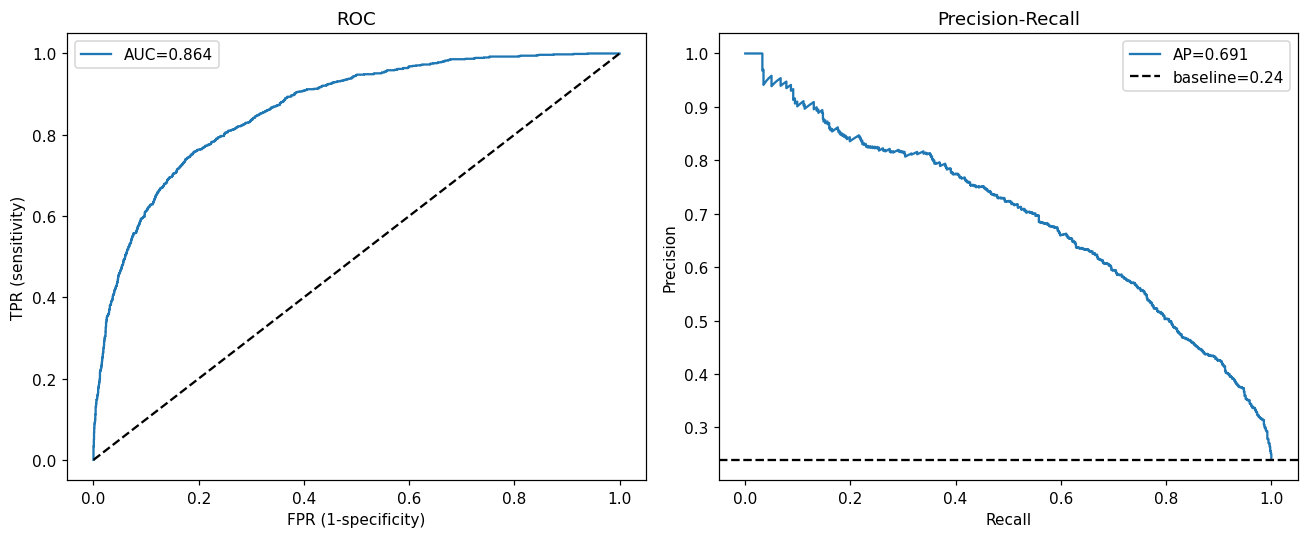

In [ ]:
fpr,tpr,_ = roc_curve(test_ys,test_probs); prec,rec,_ = precision_recall_curve(test_ys,test_probs)
roc_auc=roc_auc_score(test_ys,test_probs); pr_auc=average_precision_score(test_ys,test_probs)
print(f"ROC-AUC={roc_auc:.3f}  PR-AUC={pr_auc:.3f}  (prevalence={test_ys.mean():.3f})")
fig,ax=plt.subplots(1,2,figsize=(12,5))
ax[0].plot(fpr,tpr,label=f"AUC={roc_auc:.3f}"); ax[0].plot([0,1],[0,1],"k--")
ax[0].set_xlabel("FPR (1-specificity)"); ax[0].set_ylabel("TPR (sensitivity)"); ax[0].set_title("ROC"); ax[0].legend()
ax[1].plot(rec,prec,label=f"AP={pr_auc:.3f}"); ax[1].axhline(test_ys.mean(),ls="--",color="k",label=f"prevalence={test_ys.mean():.2f}")
ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].set_title("Precision-Recall"); ax[1].legend()
plt.tight_layout(); plt.show()

In [ ]:
fpr_v,tpr_v,thr_v = roc_curve(val_ys,val_probs); spec_v = 1-fpr_v
screen_thr  = float(thr_v[np.where(tpr_v>=0.90)[0][0]])
highspec_thr= float(thr_v[np.where(spec_v>=0.90)[0][-1]])
print(f"screening thr={screen_thr:.3f} (val sens>=0.90) | high-spec thr={highspec_thr:.3f} (val spec>=0.90)")
for name,thr in [("screening",screen_thr),("high-spec",highspec_thr)]:
    pr=(test_probs>=thr).astype(int); tn,fp,fn,tp=confusion_matrix(test_ys,pr).ravel()
    print(f"{name:9s} TEST: sens={tp/(tp+fn):.3f} spec={tn/(tn+fp):.3f} prec={tp/(tp+fp):.3f}")

screening thr=0.364 (val sens>=0.90) | high-spec thr=0.717 (val spec>=0.90)
screening TEST: sens=0.875 spec=0.646 prec=0.437
high-spec TEST: sens=0.598 spec=0.903 prec=0.660


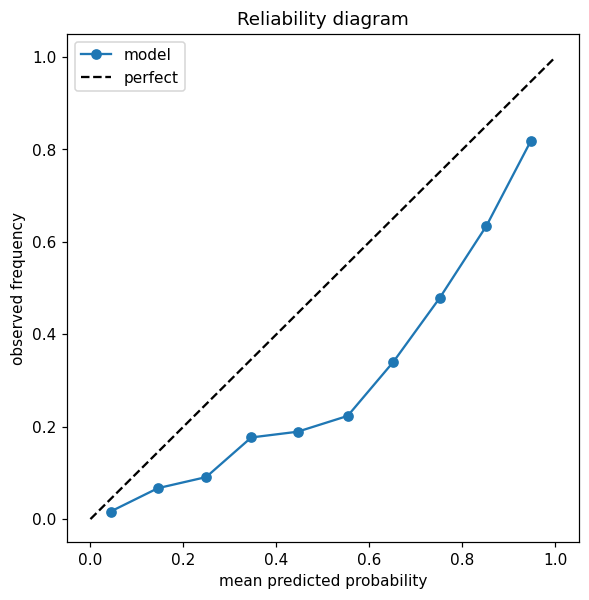

In [ ]:
frac,meanp = calibration_curve(test_ys,test_probs,n_bins=10)
plt.figure(figsize=(6,6))
plt.plot(meanp,frac,"o-",label="model"); plt.plot([0,1],[0,1],"k--",label="perfect")
plt.xlabel("mean predicted probability"); plt.ylabel("observed frequency"); plt.title("Reliability diagram"); plt.legend(); plt.show()

**Interpretation (Task F):**

- **ROC vs PR:** ROC-AUC (0.864) exceeds PR-AUC (0.691) because ROC's specificity is dominated by the large negative class, making it optimistic under imbalance. At 24% prevalence the **PR curve is more informative** (it focuses on the positive class); AP 0.69 is well above the 0.24 prevalence baseline.
- **Thresholds:** the screening (0.364) and high-specificity (0.717) thresholds were **frozen on validation** then applied to test; they transfer approximately (screening sens 0.875, high-spec spec 0.903).
- **Discrimination vs calibration:** discrimination (ranking, AUC 0.86) is strong; the reliability diagram shows the model is **not perfectly calibrated** — expected, since the `pos_weight` loss shifts predicted probabilities.

---
# Task G — Interpret predictions and analyse errors

Grad-CAM on representative TP/TN/FP/FN cases, and a subgroup analysis by projection (AP vs PA).

In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision.models as tvm

cnn = tvm.resnet18(weights=None)
cnn.conv1 = nn.Conv2d(1,64,7,2,3,bias=False)
cnn.fc = nn.Linear(512,1)
cnn.load_state_dict(torch.load("../cnn_seed42.pt", map_location="cpu"))
cnn.eval()
target_layer = cnn.layer4[-1]

def grad_cam(pid):
    x = preprocess(pid).unsqueeze(0)
    A, G = {}, {}
    h1 = target_layer.register_forward_hook(lambda m,i,o: A.__setitem__('v', o.detach()))
    h2 = target_layer.register_full_backward_hook(lambda m,gi,go: G.__setitem__('v', go[0].detach()))
    cnn.zero_grad(); out = cnn(x); out[0,0].backward()
    a, g = A['v'][0], G['v'][0]
    cam = torch.relu((g.mean(dim=(1,2))[:,None,None] * a).sum(0)); cam = cam/(cam.max()+1e-8)
    h1.remove(); h2.remove()
    cam = F.interpolate(cam[None,None],(224,224),mode="bilinear",align_corners=False)[0,0].numpy()
    return preprocess(pid)[0].numpy(), cam

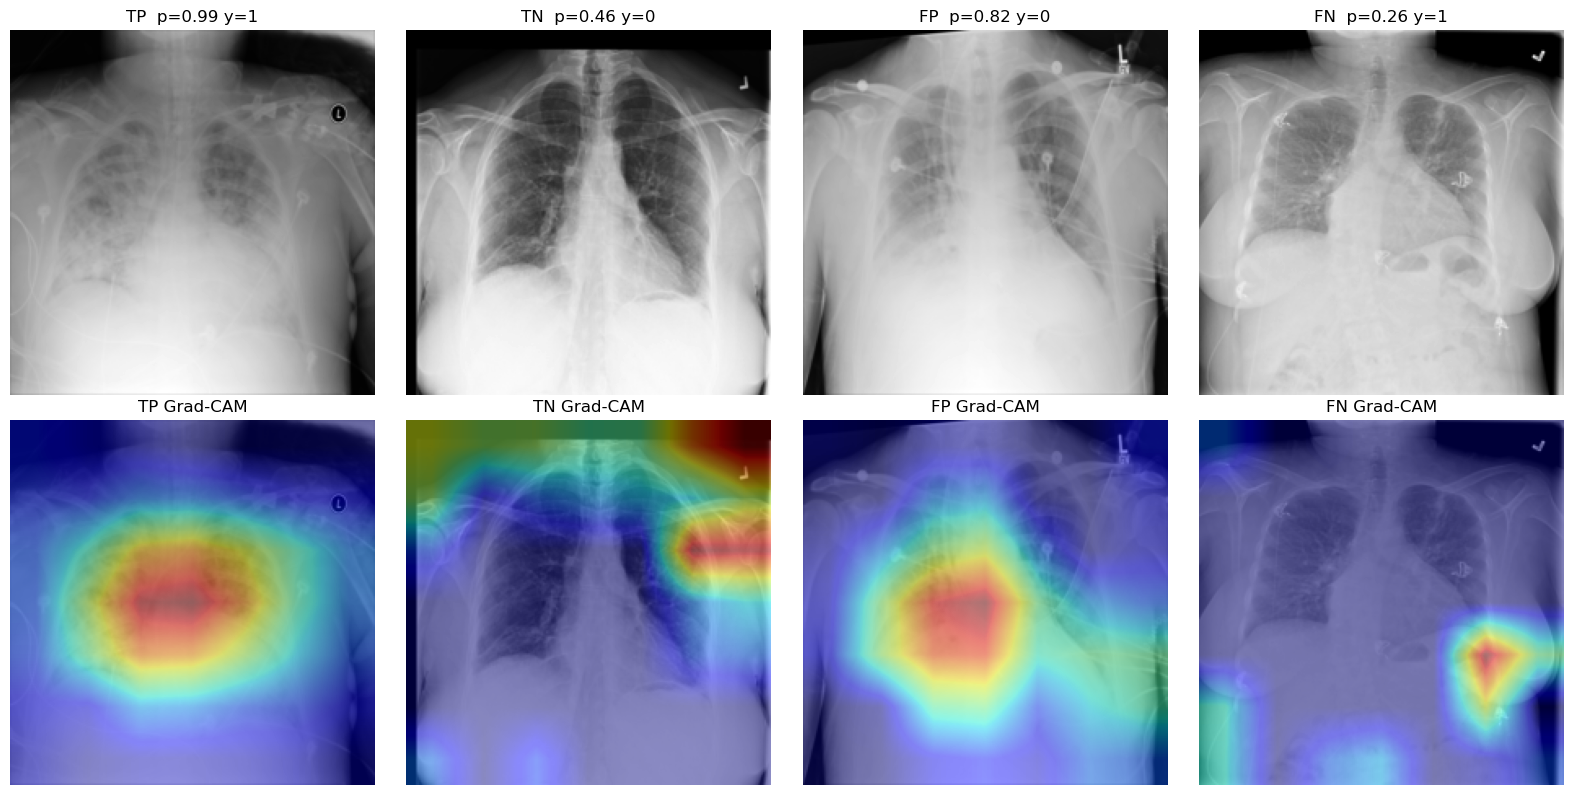

In [ ]:
test_probs = np.load("../cnn_preds_seed42.npz")["probs"]
tdf = test_df.reset_index(drop=True)
pred = (test_probs>=0.5).astype(int); true = tdf["Target"].values
pick = lambda c: np.where(c)[0][0]
cases = [(pick((pred==1)&(true==1)),"TP"),(pick((pred==0)&(true==0)),"TN"),
         (pick((pred==1)&(true==0)),"FP"),(pick((pred==0)&(true==1)),"FN")]
fig,ax=plt.subplots(2,4,figsize=(16,8))
for c,(idx,name) in enumerate(cases):
    pid=tdf.iloc[idx]["patientId"]; img,cam=grad_cam(pid)
    ax[0,c].imshow(img,cmap="gray"); ax[0,c].set_title(f"{name}  p={test_probs[idx]:.2f} y={true[idx]}"); ax[0,c].axis("off")
    ax[1,c].imshow(img,cmap="gray"); ax[1,c].imshow(cam,cmap="jet",alpha=0.45); ax[1,c].set_title(f"{name} Grad-CAM"); ax[1,c].axis("off")
plt.tight_layout(); plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score, recall_score
import pydicom
views = {pid: pydicom.dcmread(path_index[pid], stop_before_pixels=True).get("ViewPosition","UNK") for pid in tdf["patientId"]}
tdf = tdf.assign(view=tdf["patientId"].map(views)); ys=true
print("Subgroup performance (projection):")
for v in ["AP","PA"]:
    m = tdf["view"].values==v
    print(f"  {v}: n={m.sum():4d}  AUC={roc_auc_score(ys[m],test_probs[m]):.3f}  sensitivity={recall_score(ys[m],pred[m]):.3f}")

Subgroup performance (projection):
  AP: n=1822  AUC=0.820  sensitivity=0.892
  PA: n=2029  AUC=0.800  sensitivity=0.422


**Interpretation (Task G):**

- **Grad-CAM layer:** I used `layer4[-1]` (ResNet18's final convolutional block); its 7×7 feature maps retain high-level semantics while keeping enough spatial resolution to localize. Shallower layers are finer but less semantic.
- **Where the model looks:** on the clear true positive the heat-map concentrates on the **central lung fields** (anatomically sensible), but on the true-negative and false-negative it attends to **image borders/corners and marker regions** rather than lung tissue.
- **Subgroup:** sensitivity differs sharply by projection — **AP 0.892 vs PA 0.422** at threshold 0.5 (both subgroups ~2000 exams). AP films are typically portable/sicker patients with different framing and markers.
- **Shortcut discussion:** the border attention plus the large AP/PA gap are **evidence of possible non-anatomical (acquisition) signal use**. However, Grad-CAM supports inspection but does **not prove causation** — a plausible heat-map is easy to over-read. A border-masking control (Bonus 2) would be needed to confirm.